# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('inventory.db')

df= pd.read_sql_query("select * from vendor_sales_summary", conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actual_price,Volume,Total_purchase_quantity,Total_purchase_dollars,Total_sales_quantity,Total_sales_price,Total_sales_dollars,Total_excise_tax,Freight_Cost,Gross_Profit,Profit_margin,Stock_Turnover,Sales_to_purchase_ratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,672819.31,5101919.51,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,561512.37,4819073.49,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,461140.15,4538120.60,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,420050.01,4475972.88,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,545778.28,4223107.62,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,10.96,15.95,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,1.47,65.66,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,0.99,1.98,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,77.61,143.28,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [103]:
df.to_csv('vendor_sales_summary.csv',index  = False)

## Exploratory Data Analysis
- Previously we examined the various tables in database to identify key variables, understand their relationship, and determine which one should be included in the final analysis.
- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each columnn. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [54]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
Actual_price,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
Total_purchase_quantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
Total_purchase_dollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
Total_sales_quantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
Total_sales_price,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
Total_sales_dollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06


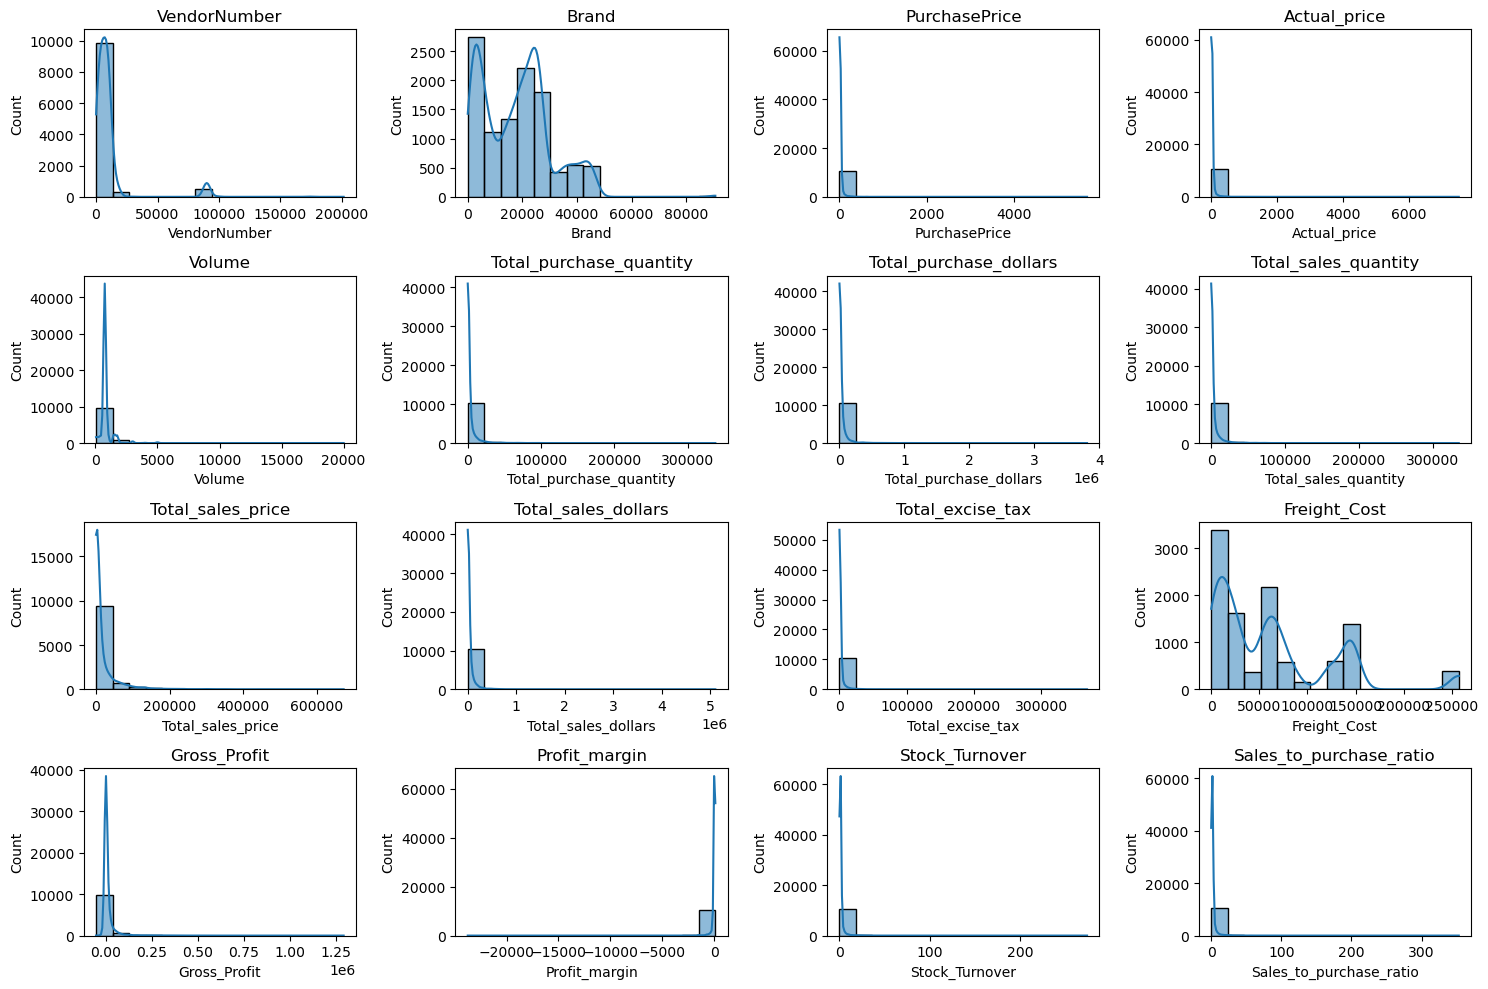

In [3]:
# Distributin plots for Numerical columns
num_cols = df.select_dtypes(include = np.number).columns # it gives yu only numerical columns

plt.figure(figsize = (15,10))
for i, col in enumerate(num_cols):  # i- index(0,1,2) and col - (column name) enumerate is a functio that gives index + value
    plt.subplot(4, 4, i+1)  # adjust grid layout as needed mean 4 rows and 4 columns i+1- position of current chart(1st column- 1st position and 2nd column- 2nd posotion)  
    sb.histplot(df[col], kde = True, bins = 15)
    plt.title(col)
plt.tight_layout() # fix equal spacing between graphs 
plt.show()

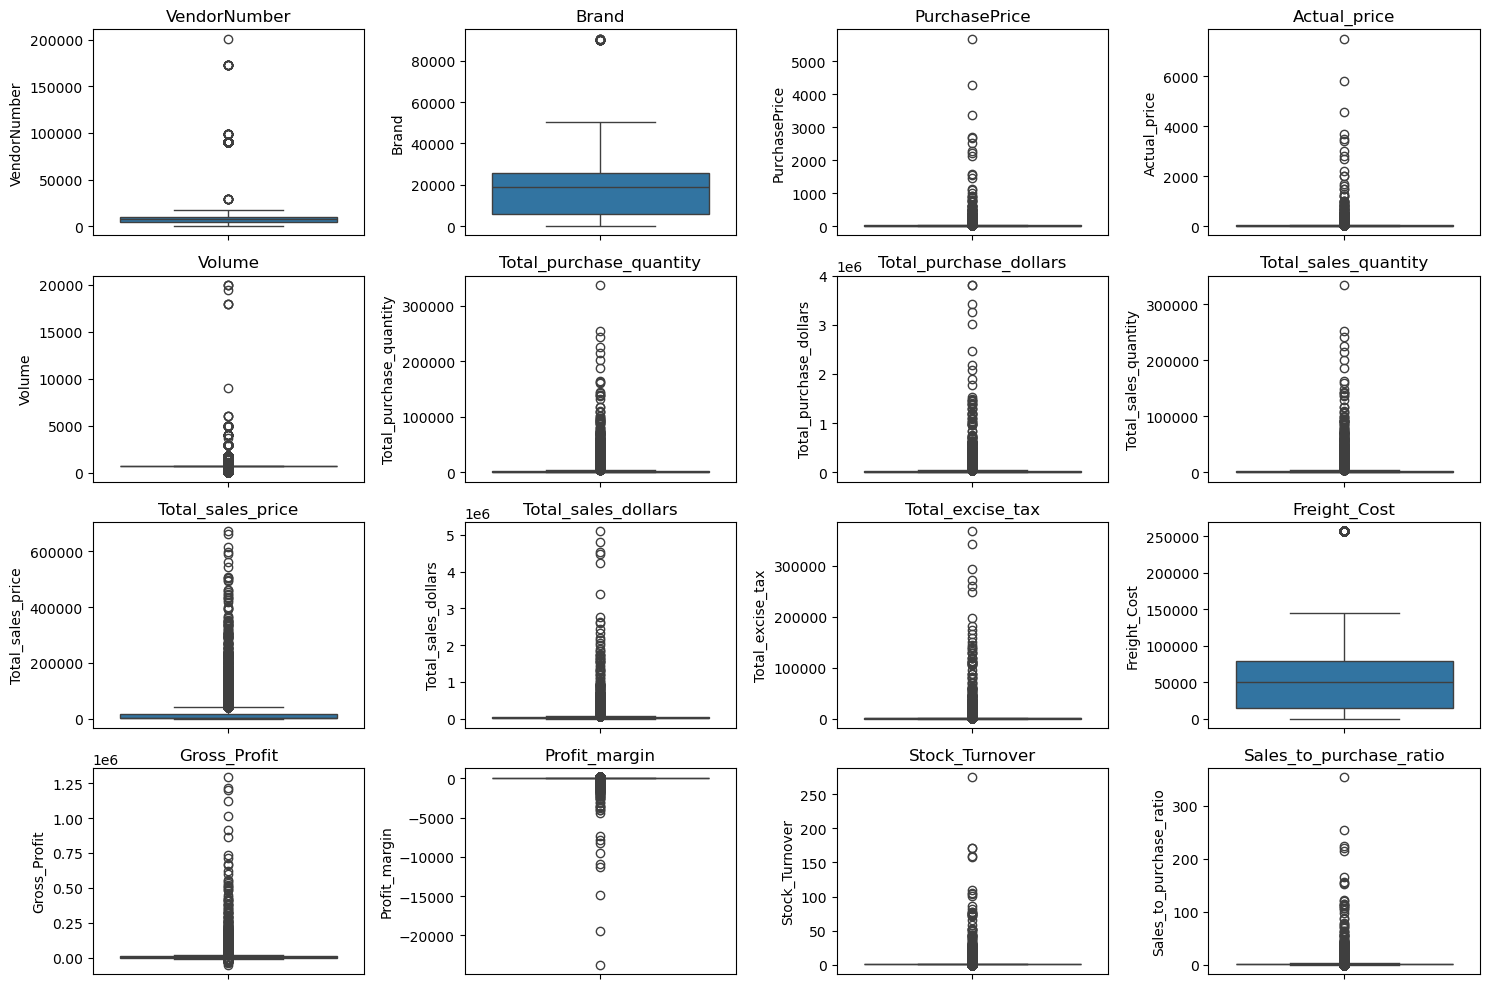

In [9]:
# Outlier detection using boxplots
plt.figure(figsize = (15,10))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sb.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary of Statistical Insights
## Negative and zero values:
- Gross Profit- Minimum value is -52,002.78, including loses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- Profit Margin- Has the minimum value of -inf, which suggests some cases where revenue is zero or even lower than costs.
- Total sales Quantity and Sales Dollars- Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.
## Outliers Indicated by High standard deviations:
- Purchase and actual Prices- The max values(5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- Frieght cost- Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover- Ranges from 0 to 274.5, implying some products are sell extremely fast while others remain in stock indefinitly. Value more than 1 indicates that Sold quantity for that product is higher than purchesed quantity due to either sales ae being fulfilled from older stock.

In [4]:
# filter the data by removing inconsistencies 
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE Gross_Profit > 0
AND Profit_Margin > 0""", conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actual_price,Volume,Total_purchase_quantity,Total_purchase_dollars,Total_sales_quantity,Total_sales_price,Total_sales_dollars,Total_excise_tax,Freight_Cost,Gross_Profit,Profit_margin,Stock_Turnover,Sales_to_purchase_ratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,672819.31,5101919.51,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,561512.37,4819073.49,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,461140.15,4538120.60,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,420050.01,4475972.88,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,545778.28,4223107.62,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,10.96,15.95,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,1.47,65.66,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,0.99,1.98,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,77.61,143.28,15.12,257032.07,141.81,98.974037,72.000000,97.469388


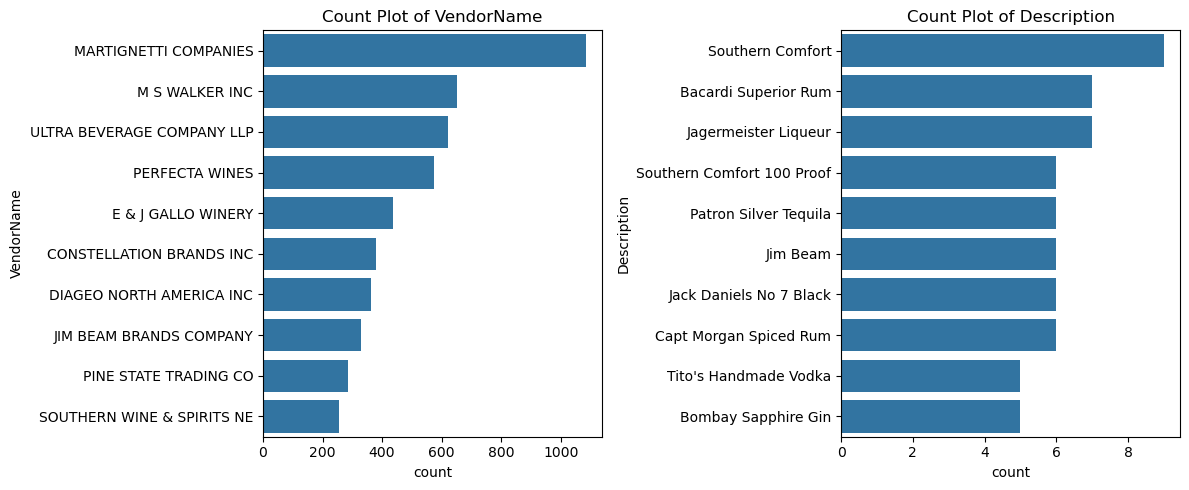

In [13]:
# Count plots fr Categorical columns
cat_cols = ["VendorName", "Description"]
plt.figure(figsize = (12,5))
for i, col in enumerate(cat_cols):
    plt.subplot(1,2,i+1)
    sb.countplot(y = df[col], order = df[col].value_counts().index[:10])  # top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()
    

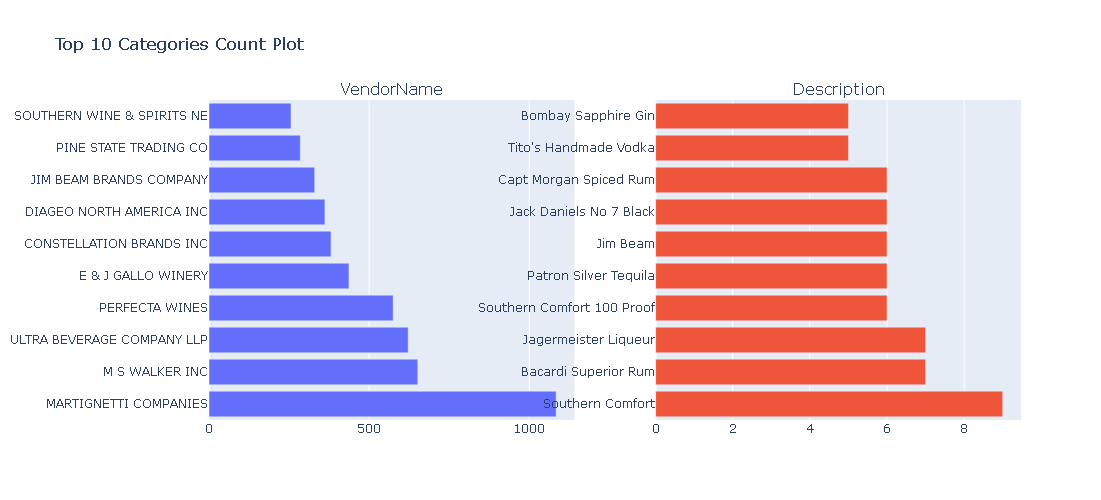

In [16]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cat_cols = ["VendorName", "Description"]

fig = make_subplots(rows=1, cols=2, subplot_titles=cat_cols)

for i, col in enumerate(cat_cols):
    top_categories = df[col].value_counts().nlargest(10)

    fig.add_trace(
        go.Bar(
            x=top_categories.values,
            y=top_categories.index,
            orientation='h'
        ),
        row=1, col=i+1
    )

fig.update_layout(
    height=500,
    width=1000,
    title_text="Top 10 Categories Count Plot",
    showlegend=False
)

fig.show()

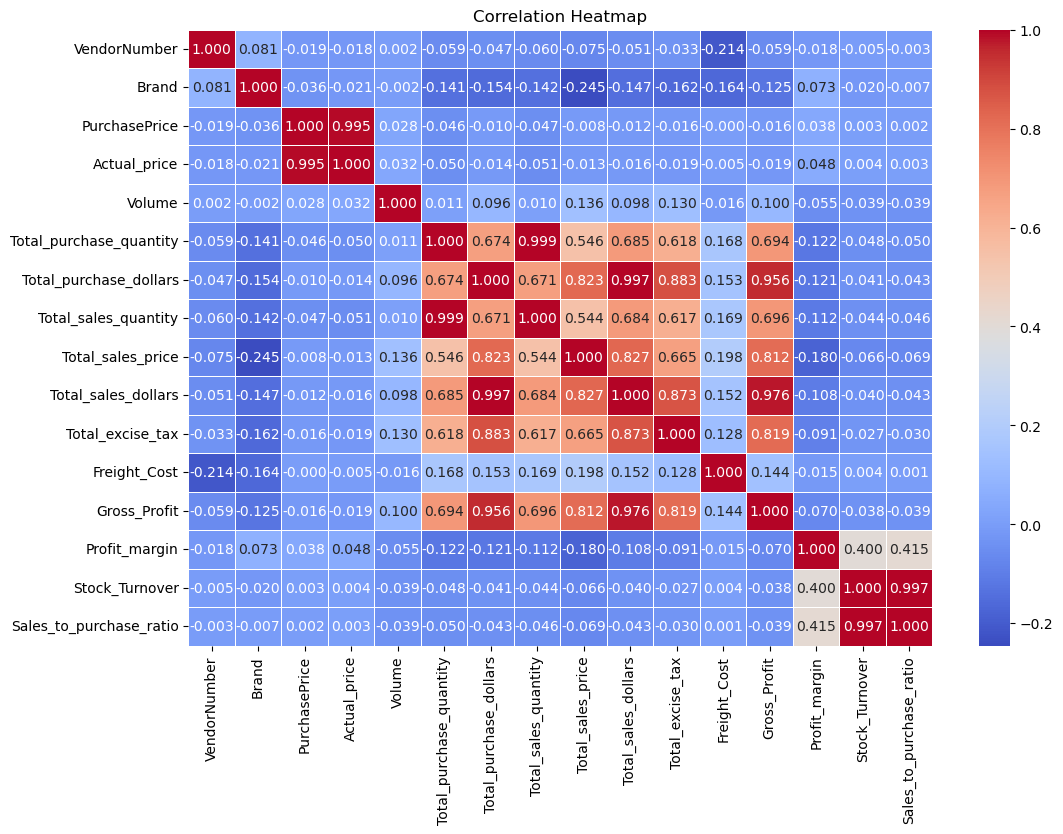

In [19]:
# Corelation Heatmap
plt.figure(figsize = (12,8))
corr_matrix = df[num_cols].corr()
sb.heatmap(corr_matrix, annot = True, fmt = ".3f", cmap = "coolwarm", linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.show()


# Correlation Insights
- Purchase price has weak correlations with Total_sales_dollars (-0.012) and gross Profit (-0.016), suggesting that price variati0ns do not significantly impact sales revenue or profit.
- Strong correlation between Total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin and total sales price (-0.180) suggests that as sales price increases, margins decreases. possibly due to competitive pricing pressures.
- Stock Turnover has weak negative correlations with both Gross Profit (-0.038) and Profit margin (-0.055). indicating that faster turnover does not necessarily in higher profitability.
- Purchase_Price <-> Actual_price = 0.99 Price are almost identical that mean vary strong correlation.
- Total_sales_dollars <-> Gross_Profit = 0.98 that means more sales = mre profit.
- Total_purchase_quantity <-> Ttal_sales_quantity = 1.00 Inventory purchase is almost fully sold.
## Negative Correlation ( 0 to -1)
#### Meaning: One increases, the other decreases
- VendorNumber has slightly negative correlation with many variables ( ~ -0.05 to 0.21). Although Vendor ID itself dosen't impact buisiness metrics.
- Profit_margins vs Total_sales_price = negative, Higher selling price may not always increase margin (possible discounting or cost issues)
## Near zero Correlation
#### Meaning: No relationship
- Volume vs many variables = 0, Vlume is not enugh stringly effecting revenue or Profit.
## Some strong insights
- Freight cost has weak correlation with sales/profit. Although logistics cost is not a major driver of profit.
- Margin: Profit margin has weak/negative correlation with sales. means increasing sales does not guarantee higher margins.
- Possible reasons: Discounts, High cost of goods.

# Data Analysis
### 1. Identify Brands that need Promotional and pricing Adjusments which exihibit lower sales Performance but higher profit margins.

In [5]:
brand_performance = df.groupby('Description').agg({
    'Total_sales_dollars':'sum',
    'Profit_margin':'mean'}).reset_index() # we took mean value because each brand has many transactions rows and each rows has its own profit margin so we need single value per head 

In [6]:
brand_performance

,Description,Total_sales_dollars,Profit_margin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [79]:
brand_performance.to_csv('brand_performance.csv',index  = False)

In [36]:
low_sales_threshold = brand_performance['Total_sales_dollars'].quantile(0.15)
high_margin_threshold = brand_performance['Profit_margin'].quantile(0.85)

In [33]:
low_sales_threshold # Only brands with sales ≤ 5060.299 are considered low sales

560.299

In [37]:
high_margin_threshold # Only brands with Profit Margin ≥ 64.97017552750113

64.97017552750113

In [40]:
target_brands = brand_performance[
(brand_performance['Total_sales_dollars'] <= low_sales_threshold) &
(brand_performance['Profit_margin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('Total_sales_dollars'))


Brands with Low Sales but High Profit Margins:


,Description,Total_sales_dollars,Profit_margin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [39]:
brand_performance = brand_performance[brand_performance['Total_sales_dollars'] < 1000] # for better visualization

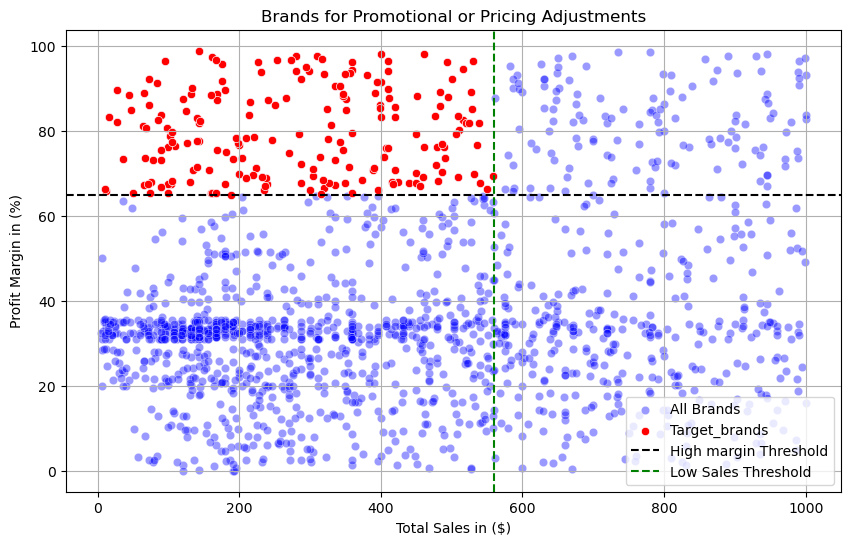

In [48]:
plt.figure(figsize = (10,6))
sb.scatterplot(data = brand_performance, x = 'Total_sales_dollars', y = 'Profit_margin', color = 'blue', label = 'All Brands', alpha = 0.4)
sb.scatterplot(data = target_brands, x = 'Total_sales_dollars', y = 'Profit_margin', color = 'red', label = 'Target_brands')

plt.axhline(high_margin_threshold, linestyle = '--', color = 'black', label = 'High margin Threshold')
plt.axvline(low_sales_threshold, linestyle = '--', color = 'green', label = 'Low Sales Threshold')

plt.xlabel("Total Sales in ($)")
plt.ylabel("Profit Margin in (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

## 2. Which Vendors and brands demonstrate the highest sales performance

In [5]:
# Top vendors and brands by sales performance 
top_vendors = df.groupby('VendorName')['Total_sales_dollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['Total_sales_dollars'].sum().nlargest(10)

In [51]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: Total_sales_dollars, dtype: float64

In [52]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: Total_sales_dollars, dtype: float64

In [4]:
def format_dollars(value):
    if value >= 1_000_000:  # 1_000_000 is just a readable way of writing 1000000
        return f"{value / 1_000_000:.2f}M"  #value / 1_000_000 → converts number into millions. Example: 2,000,000 → 2
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)  # if value is less than 1000 then it will return as it is. example: 500 → 500

In [7]:
top_brands.apply(lambda x: format_dollars(x))
# top_brands.apply(format_dollars) # we can even use this there is no neccesity to use lambda function.

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: Total_sales_dollars, dtype: object

In [8]:
top_vendors.apply(lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      68.74M
MARTIGNETTI COMPANIES         40.96M
PERNOD RICARD USA             32.28M
JIM BEAM BRANDS COMPANY       31.90M
BACARDI USA INC               25.01M
CONSTELLATION BRANDS INC      24.47M
E & J GALLO WINERY            18.55M
BROWN-FORMAN CORP             18.48M
ULTRA BEVERAGE COMPANY LLP    17.80M
M S WALKER INC                15.44M
Name: Total_sales_dollars, dtype: object

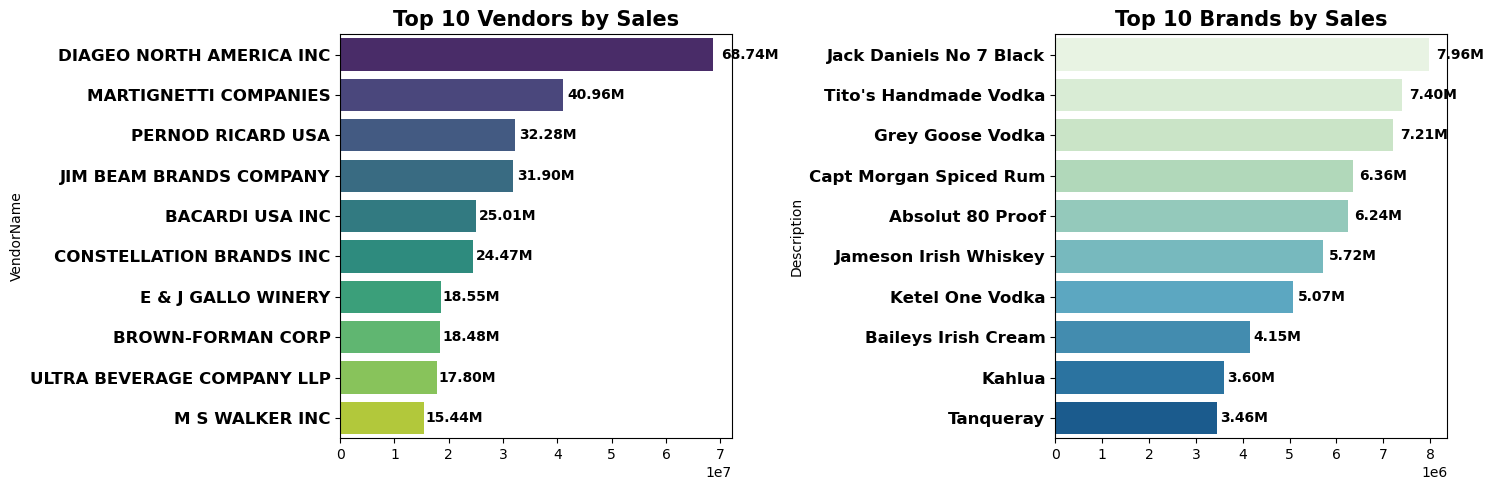

In [10]:
plt.figure(figsize = (15,5))
# plot for top vendors
plt.subplot(1,2,1)  # 1- row, 2- column, 1- first position  
ax1 = sb.barplot(y = top_vendors.index, x = top_vendors.values, palette = "viridis")
plt.setp(ax1.get_yticklabels(), fontweight='bold', fontsize=12)
plt.title("Top 10 Vendors by Sales", fontweight='bold', fontsize=15)

# Add value labels on bars
for bar in ax1.patches:   # ax1.patches = all bars in the chart
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),  # bar.get_width() → actual value (sales), + 2% → moves text slightly right of bar
             bar.get_y() + bar.get_height() / 2,  # Places text vertically centered on bar
             format_dollars(bar.get_width()), # the earlier function 
             ha ='left', va = 'center', fontsize = 10, color = 'black', fontweight='bold') # hrizontal alignment and vertical alignment

# plot for top brands
plt.subplot(1,2,2) # 1- row, 2- column, 2- first position  
ax2 = sb.barplot(y = top_brands.index.astype(str), x = top_brands.values, palette = "GnBu") # .astype(str) → ensures labels are strings (important if index is numeric)
plt.setp(ax2.get_yticklabels(), fontweight='bold', fontsize=12)
plt.title("Top 10 Brands by Sales", fontweight='bold', fontsize=15)

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha ='left', va = 'center', fontsize = 10, color = 'black', fontweight='bold')
# if there is warning then use - sb.barplot(..., hue=top_vendors.index, legend=False, palette="viridis")
plt.tight_layout()
plt.show()

## 3. Which Vendors contribute the most to total purchase dollars

In [26]:
vendor_performance = df.groupby('VendorName').agg({
    'Total_purchase_dollars':'sum',
    'Gross_Profit':'sum',
    'Total_sales_dollars':'sum'
}).reset_index() # It resets the index back to default (0,1,2,3...) and moves the old index into a normal column

In [27]:
vendor_performance['Contribution in (%)'] = vendor_performance['Total_purchase_dollars'] / vendor_performance['Total_purchase_dollars'].sum() *100
# to create this column we are dividing total_purchase_dollars by the total sum of total_purchas_dollars and multiply by 100 to get the percentage
# and we are storing these values in column named contribution in (%) 

In [28]:
vendor_performance = round(vendor_performance.sort_values('Contribution in (%)', ascending = False), 2)

In [25]:
vendor_performance

,VendorName,Total_purchase_dollars,Gross_Profit,Total_sales_dollars,Contribution in (%)
28,DIAGEO NORTH AMERICA INC,50959796.85,17780038.12,68739834.97,15.83
63,MARTIGNETTI COMPANIES,27861690.02,13098427.80,40960117.82,8.66
50,JIM BEAM BRANDS COMPANY,24203151.05,7695470.11,31898621.16,7.52
74,PERNOD RICARD USA,24124091.56,8155452.61,32279544.17,7.49
8,BACARDI USA INC,17624378.72,7380987.07,25005365.79,5.48
...,...,...,...,...,...
36,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
0,AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00,0.00
91,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
19,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [29]:
top_vendors = vendor_performance.head(10)

In [34]:
top_vendors

,VendorName,Total_purchase_dollars,Gross_Profit,Total_sales_dollars,Contribution in (%)
28,DIAGEO NORTH AMERICA INC,50959796.85,17780038.12,68739834.97,15.83
63,MARTIGNETTI COMPANIES,27861690.02,13098427.80,40960117.82,8.66
50,JIM BEAM BRANDS COMPANY,24203151.05,7695470.11,31898621.16,7.52
74,PERNOD RICARD USA,24124091.56,8155452.61,32279544.17,7.49
8,BACARDI USA INC,17624378.72,7380987.07,25005365.79,5.48
23,CONSTELLATION BRANDS INC,15573917.90,8893216.33,24467134.23,4.84
14,BROWN-FORMAN CORP,13529433.08,4947178.52,18476611.60,4.20
114,ULTRA BEVERAGE COMPANY LLP,13210613.93,4592032.17,17802646.10,4.10
33,E & J GALLO WINERY,12289608.09,6264166.57,18553774.66,3.82
59,M S WALKER INC,10935817.30,4500248.96,15436066.26,3.40


In [30]:
top_vendors['Total_sales_dollars'] = top_vendors['Total_sales_dollars'].apply(format_dollars)
top_vendors['Total_purchase_dollars'] = top_vendors['Total_purchase_dollars'].apply(format_dollars)
top_vendors['Gross_Profit'] = top_vendors['Gross_Profit'].apply(format_dollars)

In [32]:
top_vendors['Cumulative_Contribution (%)'] = top_vendors['Contribution in (%)'].cumsum()
top_vendors

,VendorName,Total_purchase_dollars,Gross_Profit,Total_sales_dollars,Contribution in (%),Cumulative_Contribution (%)
28,DIAGEO NORTH AMERICA INC,50.96M,17.78M,68.74M,15.83,15.83
63,MARTIGNETTI COMPANIES,27.86M,13.10M,40.96M,8.66,24.49
50,JIM BEAM BRANDS COMPANY,24.20M,7.70M,31.90M,7.52,32.01
74,PERNOD RICARD USA,24.12M,8.16M,32.28M,7.49,39.50
8,BACARDI USA INC,17.62M,7.38M,25.01M,5.48,44.98
23,CONSTELLATION BRANDS INC,15.57M,8.89M,24.47M,4.84,49.82
14,BROWN-FORMAN CORP,13.53M,4.95M,18.48M,4.20,54.02
114,ULTRA BEVERAGE COMPANY LLP,13.21M,4.59M,17.80M,4.10,58.12
33,E & J GALLO WINERY,12.29M,6.26M,18.55M,3.82,61.94
59,M S WALKER INC,10.94M,4.50M,15.44M,3.40,65.34


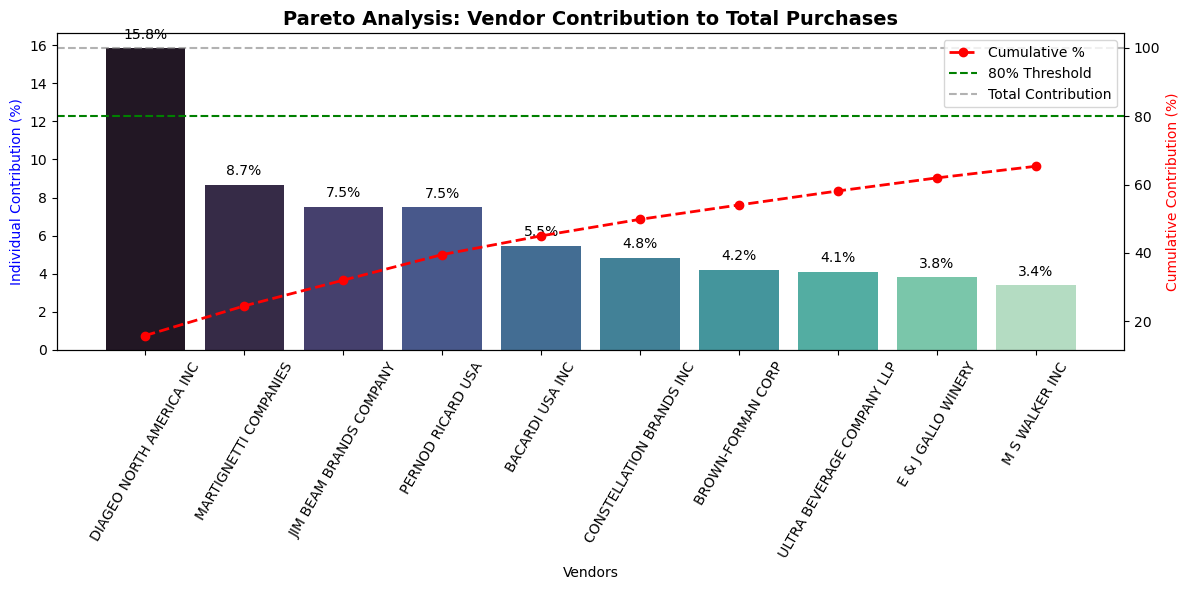

In [33]:
# Step 1: Create figure
fig, ax1 = plt.subplots(figsize=(12, 6))  # beacause it can manageable easily rather than plt figure

# Step 2: Bar plot (fixed seaborn warning)
sb.barplot(
    x='VendorName',
    y='Contribution in (%)',
    data=top_vendors,
    hue='VendorName',  # required for palette
    palette='mako',
    legend=False,   # don't show legend beacause we have given hue vendor name so it will think I should create a legend for colors
                    # Each bar already has a label (VendorName on x-axis), Legend becomes duplicate and messy  
    ax=ax1          # It tells Seaborn: Draw this plot on the axis called ax1
)

# Step 3: Add value labels on bars
for i, value in enumerate(top_vendors['Contribution in (%)']): # i → position on x-axis, value → contribution%, 
    ax1.text(i, value + 0.5, f"{value:.1f}%", ha='center', fontsize=10) # value + 0.5 → moves text slightly above bar

# Step 4: Secondary axis for cumulative line
ax2 = ax1.twinx() # a second Y-axis on the right side

# Step 5: Line plot
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution (%)'],
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Cumulative %'
)

# Step 6: Reference lines (Pareto)
ax2.axhline(y=80, color='green', linestyle='dashed', linewidth=1.5, label='80% Threshold')
ax2.axhline(y=100, color='grey', linestyle='dashed', alpha=0.6, label = 'Total Contribution')

# Step 7: Clean axis formatting (NO warnings)
ax1.tick_params(axis='x', rotation=60)

ax1.set_ylabel('Individual Contribution (%)', color='blue')
ax2.set_ylabel('Cumulative Contribution (%)', color='red')
ax1.set_xlabel('Vendors')

# Step 8: Title
ax1.set_title(
    'Pareto Analysis: Vendor Contribution to Total Purchases',
    fontsize=14,
    fontweight='bold'
)

# Step 9: Legend
ax2.legend(loc='upper right')

# Step 10: Layout + show
plt.tight_layout()
plt.show()


## 4. How much of total procurement is dependent on the top vendors  
- Means: Total money spent on purchasing (buying goods from vendors)
- The question is asking: Out of all the money we spend, what % goes to the top vendors

In [38]:
print(f"Total Purchase Contribution of top 10 Vendors is {round(top_vendors['Contribution in (%)'].sum(),2)} %")

Total Purchase Contribution of top 10 Vendors is 65.34 %


Total Purchase Contribution of top 10 Vendors is 65.34 %


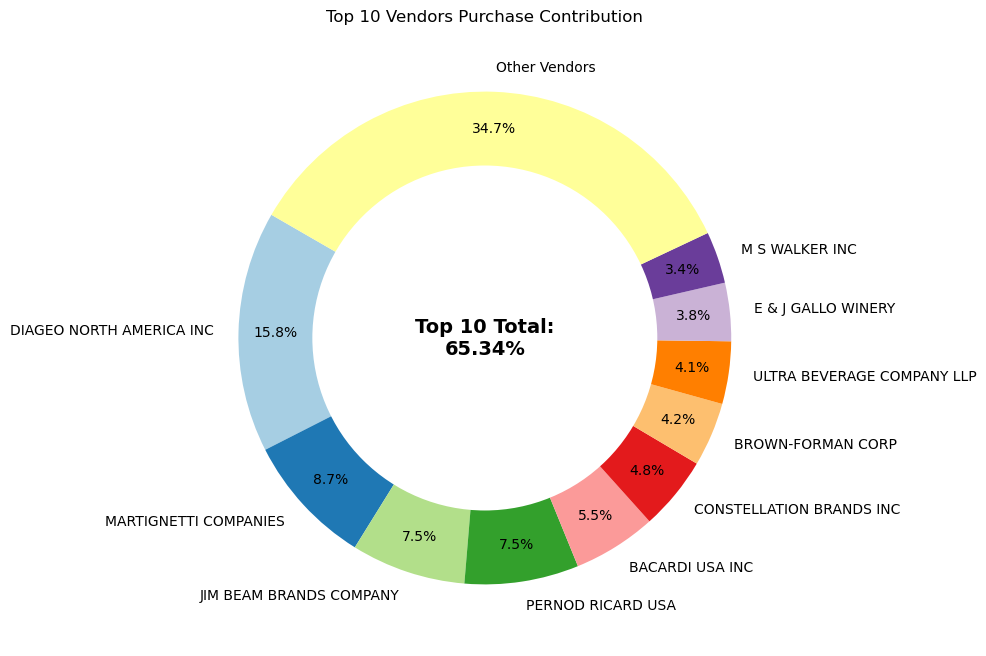

In [35]:
print(f"Total Purchase Contribution of top 10 Vendors is {round(top_vendors['Contribution in (%)'].sum(),2)} %")

vendors = list(top_vendors['VendorName'].values) # Converts dataframe columns → Python lists
purchase_contri = list(top_vendors['Contribution in (%)'].values)

# total contribution of top 10 vendors
total_contri = sum(purchase_contri) # % of top 10 vendors
remaining_contri = 100 - total_contri # % of all other vendors

# append "Other Vendors"
vendors.append("Other Vendors")
purchase_contri.append(remaining_contri)

# donut chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(   # wedges → slice shapes, texts → labels (vendor names), autotexts → percentage text
    purchase_contri,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=150,
    pctdistance=0.85, # Moves % text inward
    colors=plt.cm.Paired.colors
)

# create donut hole (converting pie into donut chart)
centre_circle = plt.Circle((0, 0), 0.70, fc='white') # 0,0 centre and 0.70 is radius
fig.gca().add_artist(centre_circle) # Get Current Axes(gca), fig.gca() - current plotting area (axis) means ax,
                                    # add_artist() - Add a custom shape/object to the plot

# center text
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contri:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendors Purchase Contribution")
plt.show()

- The remaining vendors contribute only 34.7%, meaning they are not utilized effectively or may not be as competitive.
- If vendor dependency is too high, consider identifying new suppliers to reduce risk.

### 5. Does Purchasing bulk reduce the unit price, and what is the optimal purchase volume for cost savings

In [83]:
# calculate unit purchase price per vendor and volume group
df["Unit_Purchase_Price"] = df["Total_purchase_dollars"] / df["Total_purchase_quantity"]

# Group the order size (e.g., Small, Medium, Large Purchases)
df["Order_Size"] = pd.qcut(df["Total_purchase_quantity"], q = 3, labels = ["Small", "Medium", "Large"])
# qcut - It divides data into equal-sized groups (quantiles)
# Analyze Cost Savings per Order Size
bulk_purchase = df.groupby("Order_Size", observed = True)["Unit_Purchase_Price"].mean().reset_index()
print(bulk_purchase)     

  Order_Size  Unit_Purchase_Price
0      Small            43.776954
1     Medium            17.894005
2      Large            11.308807


- This shows a significant reduction in unit purchase price as order size increases. Large orders cost ~74% less per unit compared to small orders, indicating strong economies of scale. This suggests that consolidating purchases into larger orders can lead to substantial cost savings.
- Basically it means if we buy in large order size then we can get price per unit lesser than in medium and small order size 

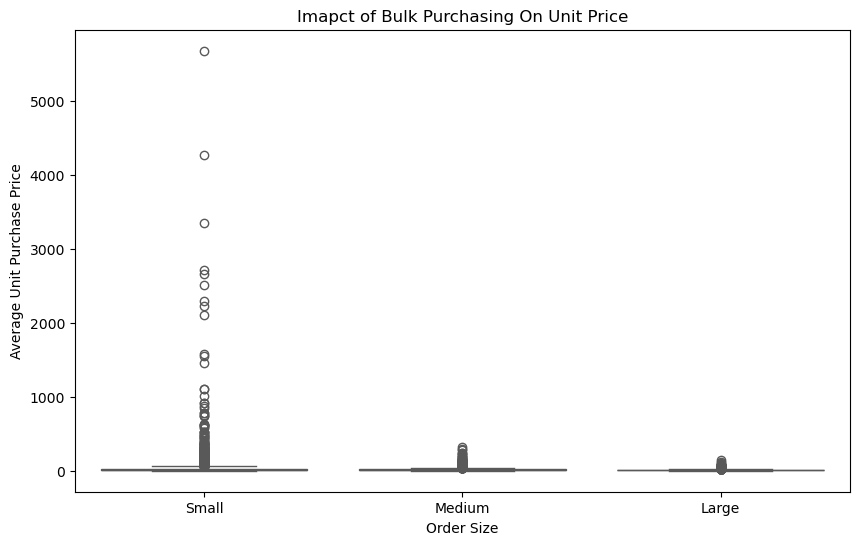

In [71]:
plt.figure(figsize = (10,6))
sb.boxplot(
    data=df,
    x="Order_Size",
    y="Unit_Purchase_Price",
    hue="Order_Size",      
    palette="Set2",
    legend=False           
)
plt.title("Imapct of Bulk Purchasing On Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (large order size) get the lowest unit price ($11.30 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~74% reduction in unit cost).
- This suggest that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower unit price revenue.  

### 6. Which Vendors have low inventory turnover, indicating excess stock ad slow-moving products 
- Inventory Turnover means: How quickly inventory is sold and replaced
- In simple terms: Which vendor's products are not selling fast

In [38]:
low_turnover_vendors = df.groupby("VendorName")["Stock_Turnover"].mean().reset_index()

In [ ]:
zero_turnover = low_turnover_vendors[
    low_turnover_vendors["Stock_Turnover"] == 0
]

In [ ]:
low_nonzero = low_turnover_vendors[
    (low_turnover_vendors["Stock_Turnover"] > 0) &
    (low_turnover_vendors["Stock_Turnover"] < 1)
]

In [40]:
low_turnover_vendors = low_turnover_vendors[
    (low_turnover_vendors["Stock_Turnover"] > 0) &
    (low_turnover_vendors["Stock_Turnover"] < 1)
].sort_values(by="Stock_Turnover", ascending=True)

low_turnover_vendors.head(10)  

,VendorName,Stock_Turnover
112,TRUETT HURST,0.041667
119,VINEYARD BRANDS LLC,0.256241
45,HIGHLAND WINE MERCHANTS LLC,0.303662
57,LOYAL DOG WINERY,0.308333
10,BLACK COVE BEVERAGES,0.340588
115,UNCORKED,0.347699
42,GILMANTON WINERY & VINEYARD,0.465819
6,APPOLO VINEYARDS LLC,0.472727
93,SOUTHERN GLAZERS W&S OF NE,0.530325
107,TAMWORTH DISTILLING,0.592584


In [41]:
df[df["Total_sales_quantity"] > df["Total_purchase_quantity"]]

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actual_price,Volume,Total_purchase_quantity,Total_purchase_dollars,Total_sales_quantity,Total_sales_price,Total_sales_dollars,Total_excise_tax,Freight_Cost,Gross_Profit,Profit_margin,Stock_Turnover,Sales_to_purchase_ratio
5,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,141860.0,446932.09,3383912.40,111699.19,89286.27,917276.47,27.106980,1.021980,1.371873
12,480,BACARDI USA INC,2663,Dewars White Label,21.42,29.99,1750.0,69001,1478001.42,70122.0,495957.83,2189368.78,128839.08,89286.27,711367.36,32.491893,1.016246,1.481304
17,3960,DIAGEO NORTH AMERICA INC,8082,Baileys Irish Cream,21.73,33.99,1750.0,64249,1396130.77,65184.0,494487.65,2068091.16,119767.49,257032.07,671960.39,32.491817,1.014553,1.481302
18,3960,DIAGEO NORTH AMERICA INC,8680,Crown Royal,28.88,39.99,1750.0,47546,1373128.48,47966.0,596574.93,1884307.34,88129.80,257032.07,511178.86,27.128210,1.008834,1.372273
27,480,BACARDI USA INC,4243,Bacardi Superior Rum,14.49,19.99,1750.0,76389,1106876.61,77041.0,342678.85,1657809.59,141551.61,89286.27,550932.98,33.232585,1.008535,1.497737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10686,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,14.0,5.97,27.86,0.73,257032.07,25.02,89.806174,7.000000,9.809859
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,10.96,15.95,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,1.47,65.66,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,77.61,143.28,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [5]:
df["Unsold_Units"] = df["Total_purchase_quantity"] - df["Total_sales_quantity"]

df['Unsold_Units'] = df['Unsold_Units'].clip(lower = 0)

df['Unsold_Inventory_Value'] = df['Unsold_Units'] * df['PurchasePrice']
print('Total Unsold Capital:', format_dollars(df["Unsold_Inventory_Value"].sum()))

Total Unsold Capital: 15.60M


In [53]:
# Calculate Unsold Inventory Value


# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["Unsold_Inventory_Value"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="Unsold_Inventory_Value", ascending=False)
inventory_value_per_vendor['Unsold_Inventory_Value'] = inventory_value_per_vendor['Unsold_Inventory_Value'].apply(format_dollars)
inventory_value_per_vendor.head(10)

Total Unsold Capital: 15.60M


,VendorName,Unsold_Inventory_Value
63,MARTIGNETTI COMPANIES,1.93M
28,DIAGEO NORTH AMERICA INC,1.66M
114,ULTRA BEVERAGE COMPANY LLP,1.48M
50,JIM BEAM BRANDS COMPANY,1.14M
73,PERFECTA WINES,915.64K
59,M S WALKER INC,850.05K
74,PERNOD RICARD USA,723.10K
125,WILLIAM GRANT & SONS INC,502.62K
33,E & J GALLO WINERY,486.89K
23,CONSTELLATION BRANDS INC,448.59K


- Our Observation: With .clip(lower=0) Total Unsold Capital is 15.60M but  Without .clip() Total Unsold Capital is  8.70M
- Core reason: Sales > Purchase means Unsold = negative
- Purchased = 100, Sold = 150, Unsold = 100 - 150 = -50, Value = -50 × price = NEGATIVE VALUE
- These negative values: reduce your total unsold capital
- with .clip(lower=0) negavive values converts to 0
- 15.60M - 8.70M = 6.90M: You had ~6.9M worth of negative inventory values
- Negative unsold inventory values occurred where sales exceeded purchases, likely due to timing differences or pre-existing stock. To ensure accurate estimation of unsold capital, I applied a lower bound of zero using .clip(), preventing distortion in total inventory valuation.
- we can check the data by using df[df["Total_sales_quantity"] > df["Total_purchase_quantity"]]
	                 
          
            

### 6. What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.
- Confidence Interval: A range where the true average value is likely to fall.
- 95% Confidence Interval: We are 95% confident that the true average profit margin lies in this range
- formula use: CI = xˉ ± Z⋅ s/rot(n) where xˉ → average profit margin, s → standard deviation, n → number of observations, Z → 1.96 (for 95% confidence) 


In [43]:
top_threshold = df["Total_sales_dollars"].quantile(0.75)
low_threshold = df["Total_sales_dollars"].quantile(0.25)

In [46]:
top_threshold, low_threshold

(28396.915, 729.22)

In [56]:
top_vendors = df[df["Total_sales_dollars"] >= top_threshold]["Profit_margin"].dropna( # if there is any nan value it will drop those values
low_vendors = df[df["Total_sales_dollars"] <= low_threshold]["Profit_margin"].dropna()

In [64]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
5530    93.085860
5648    90.021514
5651    89.883453
5773    95.012530
5945    94.271857
Name: Profit_margin, Length: 2590, dtype: float64

In [65]:
 low_vendors

7510      0.473608
7560      9.082595
7561      7.598007
7567      3.245922
7572      1.734104
           ...    
10687    83.448276
10688    96.436186
10689    25.252525
10690    98.974037
10691    99.166079
Name: Profit_margin, Length: 1528, dtype: float64

In [ ]:
# Clean low vendors
low_vendors = low_vendors.replace([np.inf, -np.inf], np.nan).dropna() 
low_vendors = low_vendors[low_vendors >= 0]

# Clean top vendors - this is additional
top_vendors = top_vendors.replace([np.inf, -np.inf], np.nan).dropna()
top_vendors = top_vendors[top_vendors >= 0]

In [66]:
def confidence_interval(data, confidence = 0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof = 1) / np.sqrt(len(data))   # standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df = len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (31.07, 31.90), Mean: 31.49
Low Vendors 95% CI: (38.05, 40.42), Mean: 39.24


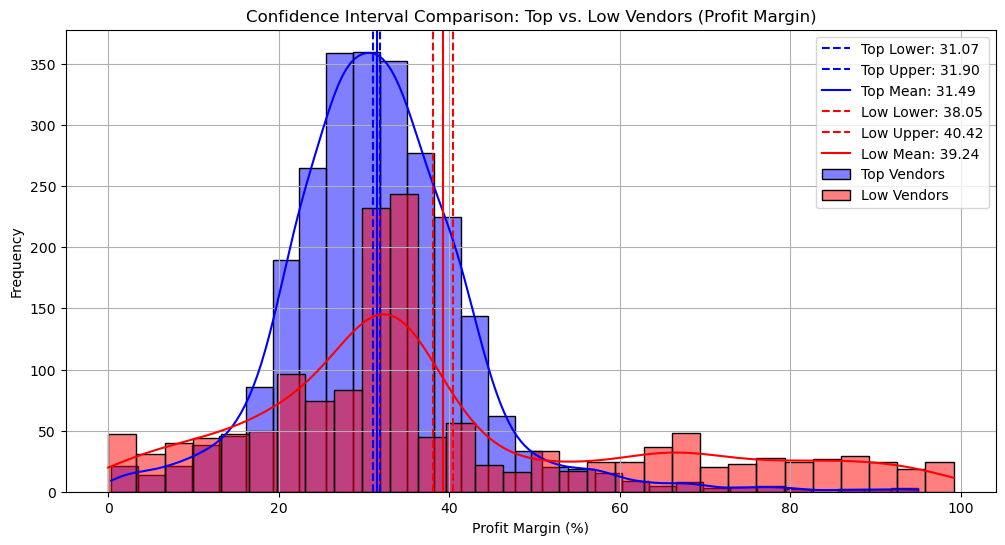

In [70]:
# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sb.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sb.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).- 
This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs
- 
For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategie
- .
For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

### 7. Is there a significant difference in profit margins between top-performing and low-performing vendors?
Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.



In [73]:
# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -12.1189, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


- A p-value this small suggests that the difference is not just statistically significant but also practically meaningful.- 
The two vendor groups operate very differently in terms of profitability.

In [74]:
df.to_csv('vendor_sales_summary.csv',index  = False)

In [ ]:
df.to_csv('brand_performance.csv',index = False)